[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/work/01_synthetic_binary_classification_dataset.ipynb)


# 3.2 Binary Classification Dataset Visualization


이 노트북은 `3-2.py`의 2차원 이진 분류 데이터 생성 및 시각화 실습을 Colab용으로 정리한 버전입니다.

## 학습 목표

- `make_classification`으로 간단한 이진 분류 데이터를 생성합니다.
- 생성된 feature/label 배열의 shape을 확인합니다.
- 2차원 feature 공간에서 class 분포를 산점도로 확인합니다.

## 진행 순서

1. 필요한 라이브러리를 불러옵니다.
2. 2차원 이진 분류 데이터를 생성합니다.
3. 데이터 크기와 class 분포를 확인합니다.
4. 산점도로 decision boundary가 필요한 구조를 관찰합니다.


In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

## 1. 데이터 생성

`n_features=2`, `n_informative=2`로 설정하면 두 feature가 모두 분류에 의미 있는 정보를 갖습니다. `random_state`를 고정해 Colab에서 다시 실행해도 같은 데이터가 나오도록 합니다.


In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    random_state=42,
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 2)
y shape: (1000,)


## 2. class 분포 확인

분류 실습에서는 label이 한쪽으로 지나치게 치우쳐 있지 않은지 먼저 확인하는 습관이 중요합니다.


In [3]:
class_counts = {label: int((y == label).sum()) for label in sorted(set(y))}
print("Class counts:", class_counts)

Class counts: {np.int64(0): 498, np.int64(1): 502}


## 3. 2차원 시각화

각 점은 하나의 sample이고, 색은 class label을 의미합니다. 두 class가 얼마나 섞여 있는지 보면 모델이 해결해야 할 난이도를 직관적으로 파악할 수 있습니다.


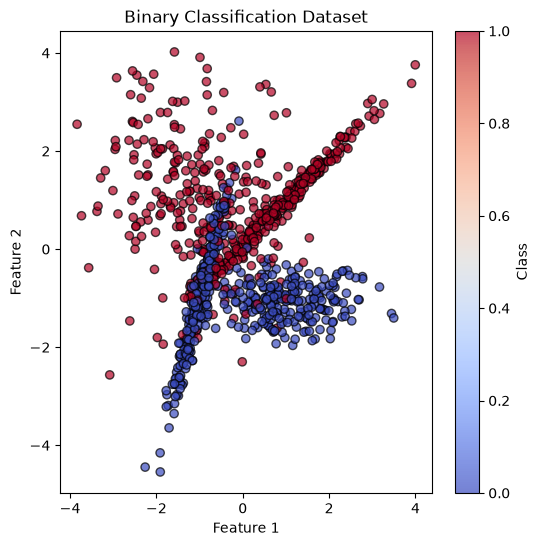

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm",
    edgecolors="k",
    alpha=0.7,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.colorbar(label="Class")
plt.show()

## 실습 과제

아래 셀에서 `class_sep` 값을 바꿔가며 class 간 분리가 어떻게 달라지는지 확인해 보세요. 값이 작을수록 두 class가 더 많이 섞입니다.


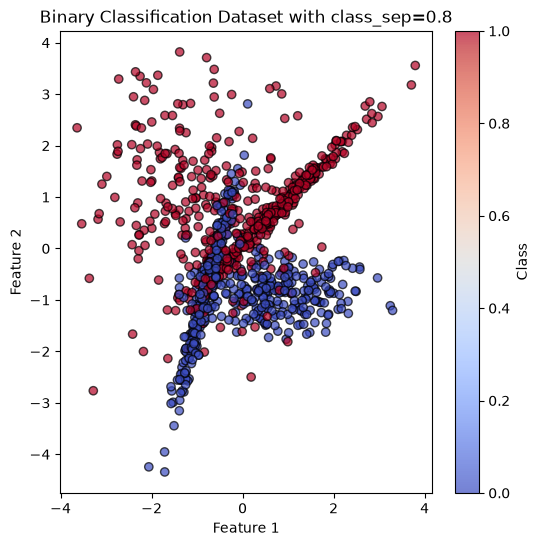

In [5]:
X_experiment, y_experiment = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    class_sep=0.8,
    random_state=42,
)

plt.figure(figsize=(6, 6))
plt.scatter(
    X_experiment[:, 0],
    X_experiment[:, 1],
    c=y_experiment,
    cmap="coolwarm",
    edgecolors="k",
    alpha=0.7,
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset with class_sep=0.8")
plt.colorbar(label="Class")
plt.show()

## 정리

- `make_classification`은 분류 문제를 빠르게 실험할 수 있는 synthetic dataset을 만듭니다.
- 2차원 데이터는 산점도만으로도 class 구조와 난이도를 확인하기 쉽습니다.
- `class_sep`, `n_informative`, `random_state` 같은 생성 조건이 데이터 구조를 크게 바꿉니다.
